In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [4]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 536641
Columns: 8


In [6]:
df.dtypes

invoiceno          str
stockcode          str
description        str
quantity         int64
invoicedate        str
unitprice      float64
customerid     float64
country            str
dtype: object

In [7]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

Numeric Columns:
['quantity', 'unitprice', 'customerid']


In [8]:
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['invoiceno', 'stockcode', 'description', 'invoicedate', 'country']


In [9]:
date_columns = df.select_dtypes(
    include=["datetime"]
).columns.tolist()

print("Date Columns:")
print(date_columns)

Date Columns:
[]


In [10]:
def generate_profile(df):

    profile = pd.DataFrame({
        "column": df.columns,
        "data_type": df.dtypes.astype(str).values,
        "missing_count": df.isnull().sum().values,
        "missing_percentage": (
            df.isnull().sum() / len(df) * 100
        ).values,
        "unique_values": [
            df[col].nunique()
            for col in df.columns
        ]
    })

    return profile

In [11]:
profile = generate_profile(df)

profile

,column,data_type,missing_count,missing_percentage,unique_values
0,invoiceno,str,0,0.0,25900
1,stockcode,str,0,0.0,4070
2,description,str,0,0.0,4211
3,quantity,int64,0,0.0,722
4,invoicedate,str,0,0.0,23260
5,unitprice,float64,0,0.0,1630
6,customerid,float64,0,0.0,4372
7,country,str,0,0.0,38


In [12]:
numeric_summary = df[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
quantity,536641.0,9.620029,219.130156,-80995.00,1.00,3.00,10.00,80995.0
unitprice,536641.0,4.632656,97.233118,-11062.06,1.25,2.08,4.13,38970.0
customerid,536641.0,15246.898157,1483.931554,12346.00,14367.00,15145.00,16241.00,18287.0


In [13]:
numeric_summary = df[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
quantity,536641.0,9.620029,219.130156,-80995.00,1.00,3.00,10.00,80995.0
unitprice,536641.0,4.632656,97.233118,-11062.06,1.25,2.08,4.13,38970.0
customerid,536641.0,15246.898157,1483.931554,12346.00,14367.00,15145.00,16241.00,18287.0


In [14]:
categorical_summary = pd.DataFrame({
    "column": categorical_columns,
    "unique_values": [
        df[col].nunique()
        for col in categorical_columns
    ],
    "most_common": [
        df[col].mode().iloc[0]
        if not df[col].mode().empty
        else None
        for col in categorical_columns
    ]
})

categorical_summary

,column,unique_values,most_common
0,invoiceno,25900,573585
1,stockcode,4070,85123A
2,description,4211,WHITE HANGING HEART T-LIGHT HOLDER
3,invoicedate,23260,2011-10-31 14:41:00
4,country,38,United Kingdom


In [15]:
for col in date_columns:

    df[f"{col}_year"] = df[col].dt.year
    df[f"{col}_month"] = df[col].dt.month
    df[f"{col}_day"] = df[col].dt.day
    df[f"{col}_dayofweek"] = df[col].dt.dayofweek

In [16]:
for col in date_columns:

    df[f"{col}_day_name"] = (
        df[col].dt.day_name()
    )

In [17]:
if len(date_columns) > 0:

    for col in date_columns:

        df[f"{col}_year"] = df[col].dt.year
        df[f"{col}_month"] = df[col].dt.month
        df[f"{col}_dayofweek"] = df[col].dt.dayofweek

In [18]:
for col in categorical_columns:

    df[f"{col}_length"] = (
        df[col]
        .astype("string")
        .str.len()
    )

In [19]:
text_columns = df.select_dtypes(
    include=["object", "string"]
).columns

In [20]:
for col in text_columns:

    if df[col].nunique() > 10:

        df[f"{col}_length"] = (
            df[col]
            .astype("string")
            .str.len()
        )

In [21]:
correlation = df[numeric_columns].corr()

correlation

,quantity,unitprice,customerid
quantity,1.000000,-0.001241,-0.002609
unitprice,-0.001241,1.000000,-0.003624
customerid,-0.002609,-0.003624,1.000000


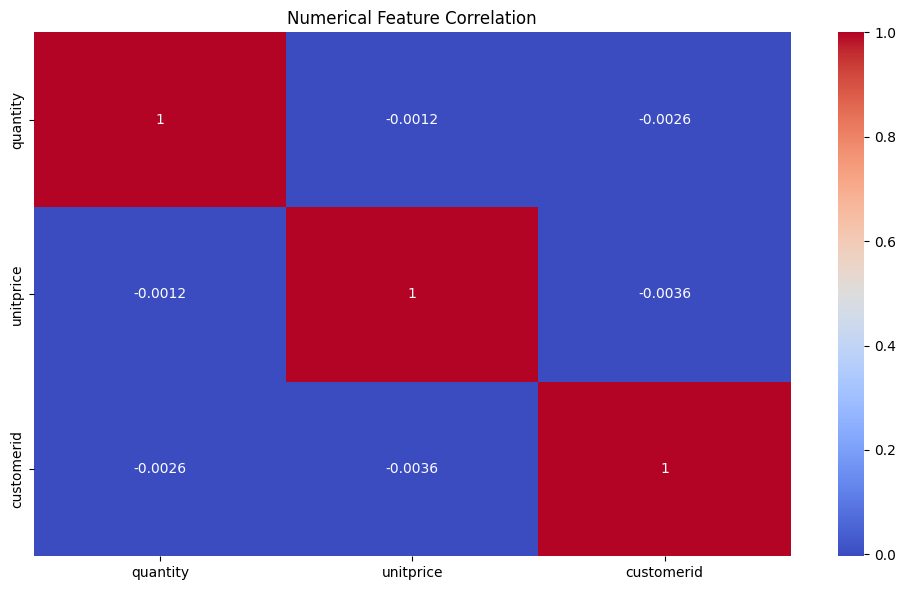

In [22]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()

In [23]:
corr_matrix = df[numeric_columns].corr()

high_corr = []

for col1 in corr_matrix.columns:

    for col2 in corr_matrix.columns:

        if col1 != col2:

            value = corr_matrix.loc[col1, col2]

            if abs(value) >= 0.8:

                high_corr.append(
                    (col1, col2, value)
                )

high_corr[:20]

[]

In [24]:
def outlier_summary(df):

    results = []

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns

    for col in numeric_columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = (
            (df[col] < lower) |
            (df[col] > upper)
        ).sum()

        results.append({
            "column": col,
            "outliers": count
        })

    return pd.DataFrame(results)

In [25]:
outlier_report = outlier_summary(df)

outlier_report


,column,outliers
0,quantity,58501
1,unitprice,39450
2,customerid,0
3,invoiceno_length,9254
4,stockcode_length,54487
5,description_length,3763
6,invoicedate_length,0
7,country_length,46311


In [26]:
numeric_missing = df[numeric_columns].isnull().sum()

numeric_missing

quantity      0
unitprice     0
customerid    0
dtype: int64

In [27]:
categorical_missing = df[categorical_columns].isnull().sum()

categorical_missing

invoiceno      0
stockcode      0
description    0
invoicedate    0
country        0
dtype: int64

In [28]:
feature_report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique": [
        df[col].nunique()
        for col in df.columns
    ],
    "missing": [
        df[col].isnull().sum()
        for col in df.columns
    ]
})

feature_report

,column,dtype,unique,missing
0,invoiceno,str,25900,0
1,stockcode,str,4070,0
2,description,str,4211,0
3,quantity,int64,722,0
4,invoicedate,str,23260,0
5,unitprice,float64,1630,0
6,customerid,float64,4372,0
7,country,str,38,0
8,invoiceno_length,Int64,2,0
9,stockcode_length,Int64,10,0


In [29]:
df.to_csv(
    "../data/processed/feature_engineered_data.csv",
    index=False
)

In [32]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.features.feature_engineering import create_features

df_test = create_features(df)

df_test.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,invoiceno_length,stockcode_length,description_length,invoicedate_length,country_length
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,6,34,19,14
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,5,19,19,14
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,6,6,30,19,14
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,35,19,14
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,30,19,14


In [33]:
df_test = create_features(df)
df_test.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,invoiceno_length,stockcode_length,description_length,invoicedate_length,country_length
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,6,34,19,14
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,5,19,19,14
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,6,6,30,19,14
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,35,19,14
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,30,19,14


In [34]:
df_test.shape

(536641, 13)

In [35]:
df.shape

(536641, 13)

In [36]:
print("Original columns:")
print(df.columns.tolist())

print("\nNew columns:")
print(df_test.columns.tolist())

Original columns:
['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'invoiceno_length', 'stockcode_length', 'description_length', 'invoicedate_length', 'country_length']

New columns:
['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'invoiceno_length', 'stockcode_length', 'description_length', 'invoicedate_length', 'country_length']


In [37]:
print("Original columns:")
print(df.columns.tolist())

print("\nNew columns:")
print(df_test.columns.tolist())

Original columns:
['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'invoiceno_length', 'stockcode_length', 'description_length', 'invoicedate_length', 'country_length']

New columns:
['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'invoiceno_length', 'stockcode_length', 'description_length', 'invoicedate_length', 'country_length']


In [38]:
date_columns = [
    col for col in df_test.columns
    if "date" in col.lower()
]

print(date_columns)


['invoicedate', 'invoicedate_length']


In [39]:
df_test.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,invoiceno_length,stockcode_length,description_length,invoicedate_length,country_length
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,6,34,19,14
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,5,19,19,14
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,6,6,30,19,14
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,35,19,14
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,30,19,14


In [40]:
df_test.dtypes

invoiceno                 str
stockcode                 str
description               str
quantity                int64
invoicedate               str
unitprice             float64
customerid            float64
country                   str
invoiceno_length        Int64
stockcode_length        Int64
description_length      Int64
invoicedate_length      Int64
country_length          Int64
dtype: object

In [41]:
missing = df_test.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [42]:
df_test.duplicated().sum()

np.int64(0)

In [43]:
numeric_columns = df_test.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric Features:")
print(numeric_columns)

Numeric Features:
['quantity', 'unitprice', 'customerid', 'invoiceno_length', 'stockcode_length', 'description_length', 'invoicedate_length', 'country_length']


In [44]:
categorical_columns = df_test.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Categorical Features:")
print(categorical_columns)

Categorical Features:
['invoiceno', 'stockcode', 'description', 'invoicedate', 'country']


In [45]:
feature_profile = pd.DataFrame({
    "column": df_test.columns,
    "data_type": [
        str(df_test[col].dtype)
        for col in df_test.columns
    ],
    "missing_values": [
        df_test[col].isnull().sum()
        for col in df_test.columns
    ],
    "unique_values": [
        df_test[col].nunique()
        for col in df_test.columns
    ]
})

feature_profile

,column,data_type,missing_values,unique_values
0,invoiceno,str,0,25900
1,stockcode,str,0,4070
2,description,str,0,4211
3,quantity,int64,0,722
4,invoicedate,str,0,23260
5,unitprice,float64,0,1630
6,customerid,float64,0,4372
7,country,str,0,38
8,invoiceno_length,Int64,0,2
9,stockcode_length,Int64,0,10


In [48]:
numeric_df = df_test.select_dtypes(include="number")

print("Numeric columns:")
print(numeric_df.columns.tolist())

print("\nNumber of numeric columns:", len(numeric_df.columns))

Numeric columns:
['quantity', 'unitprice', 'customerid', 'invoiceno_length', 'stockcode_length', 'description_length', 'invoicedate_length', 'country_length']

Number of numeric columns: 8


In [49]:
correlation = numeric_df.corr()

correlation

,quantity,unitprice,customerid,invoiceno_length,stockcode_length,description_length,invoicedate_length,country_length
quantity,1.000000,-0.001241,-0.002609,-0.023816,-0.001621,0.000807,NaN,-0.010400
unitprice,-0.001241,1.000000,-0.003624,0.058208,-0.017713,-0.043214,NaN,-0.002309
customerid,-0.002609,-0.003624,1.000000,-0.022348,0.017378,0.022970,NaN,0.385616
invoiceno_length,-0.023816,0.058208,-0.022348,1.000000,-0.060785,-0.022306,NaN,-0.036706
stockcode_length,-0.001621,-0.017713,0.017378,-0.060785,1.000000,0.169147,NaN,0.048406
description_length,0.000807,-0.043214,0.022970,-0.022306,0.169147,1.000000,NaN,0.030004
invoicedate_length,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_length,-0.010400,-0.002309,0.385616,-0.036706,0.048406,0.030004,NaN,1.000000


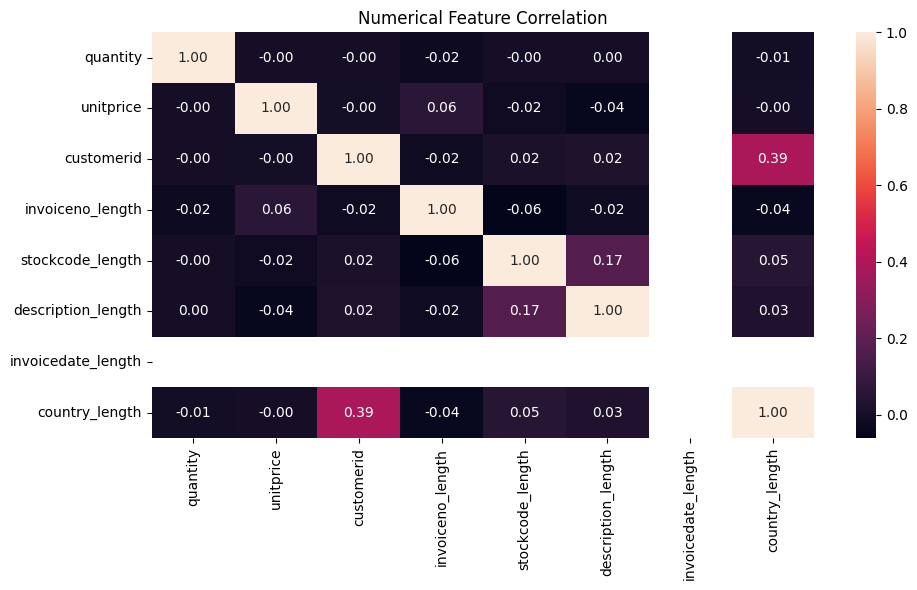

In [50]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()

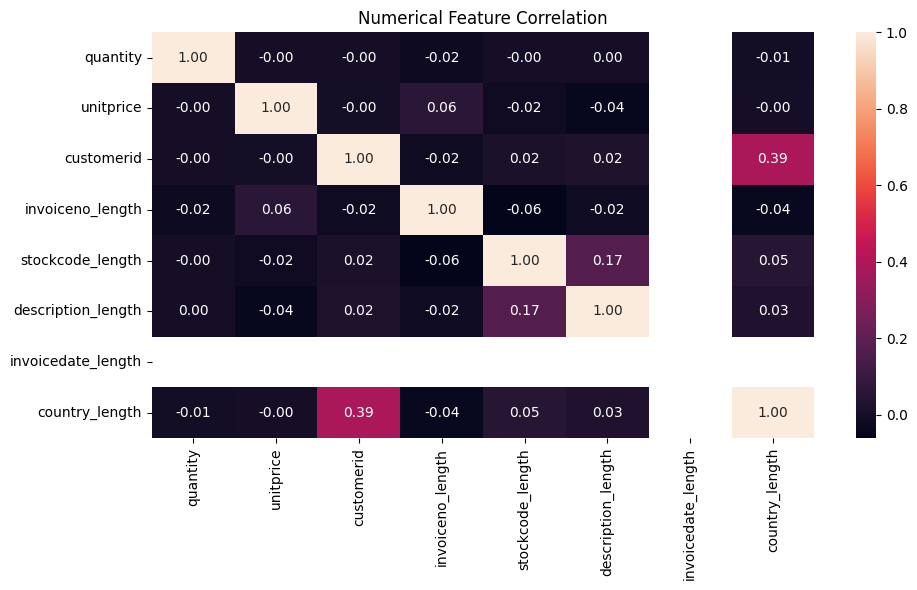

In [51]:
if len(numeric_df.columns) >= 2:

    correlation = numeric_df.corr()

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f"
    )

    plt.title("Numerical Feature Correlation")
    plt.tight_layout()
    plt.show()

else:
    print("Correlation analysis requires at least 2 numeric columns.")
    

In [52]:
numeric_df = df_test.select_dtypes(include="number")

if numeric_df.shape[1] >= 2:
    corr_matrix = numeric_df.corr()
    print(corr_matrix)
else:
    print("Not enough numeric columns for correlation analysis.")

                    quantity  unitprice  customerid  invoiceno_length  \
quantity            1.000000  -0.001241   -0.002609         -0.023816   
unitprice          -0.001241   1.000000   -0.003624          0.058208   
customerid         -0.002609  -0.003624    1.000000         -0.022348   
invoiceno_length   -0.023816   0.058208   -0.022348          1.000000   
stockcode_length   -0.001621  -0.017713    0.017378         -0.060785   
description_length  0.000807  -0.043214    0.022970         -0.022306   
invoicedate_length       NaN        NaN         NaN               NaN   
country_length     -0.010400  -0.002309    0.385616         -0.036706   

                    stockcode_length  description_length  invoicedate_length  \
quantity                   -0.001621            0.000807                 NaN   
unitprice                  -0.017713           -0.043214                 NaN   
customerid                  0.017378            0.022970                 NaN   
invoiceno_length      

In [53]:
high_correlation = []

if numeric_df.shape[1] >= 2:

    corr_matrix = numeric_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):

            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]

            value = corr_matrix.iloc[i, j]

            if abs(value) >= 0.8:
                high_correlation.append({
                    "feature_1": col1,
                    "feature_2": col2,
                    "correlation": value
                })

high_corr_df = pd.DataFrame(high_correlation)

high_corr_df

""


In [54]:
def outlier_summary(df):

    results = []

    numeric_columns = df.select_dtypes(
        include="number"
    ).columns

    for col in numeric_columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = (
            (df[col] < lower) |
            (df[col] > upper)
        ).sum()

        percentage = (
            count / len(df) * 100
        )

        results.append({
            "column": col,
            "outliers": count,
            "percentage": round(percentage, 2)
        })

    return pd.DataFrame(results)

In [55]:
outlier_report = outlier_summary(df_test)

outlier_report

,column,outliers,percentage
0,quantity,58501,10.90
1,unitprice,39450,7.35
2,customerid,0,0.00
3,invoiceno_length,9254,1.72
4,stockcode_length,54487,10.15
5,description_length,3763,0.70
6,invoicedate_length,0,0.00
7,country_length,46311,8.63


In [56]:
print("Rows:", df_test.shape[0])
print("Columns:", df_test.shape[1])

print("\nMissing Values:")
print(df_test.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_test.duplicated().sum())

Rows: 536641
Columns: 13

Missing Values:
0

Duplicate Rows:
0


In [57]:
feature_profile = pd.DataFrame({
    "column": df_test.columns,
    "data_type": [
        str(df_test[col].dtype)
        for col in df_test.columns
    ],
    "missing_values": [
        df_test[col].isnull().sum()
        for col in df_test.columns
    ],
    "unique_values": [
        df_test[col].nunique()
        for col in df_test.columns
    ]
})

feature_profile

,column,data_type,missing_values,unique_values
0,invoiceno,str,0,25900
1,stockcode,str,0,4070
2,description,str,0,4211
3,quantity,int64,0,722
4,invoicedate,str,0,23260
5,unitprice,float64,0,1630
6,customerid,float64,0,4372
7,country,str,0,38
8,invoiceno_length,Int64,0,2
9,stockcode_length,Int64,0,10


In [58]:
final_df = create_features(df)

In [59]:
final_df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,invoiceno_length,stockcode_length,description_length,invoicedate_length,country_length
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,6,34,19,14
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,5,19,19,14
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,6,6,30,19,14
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,35,19,14
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,30,19,14


In [60]:
final_df.shape

(536641, 13)

In [61]:
final_df.to_csv(
    "../data/processed/feature_engineered_data.csv",
    index=False
)

In [63]:
test_df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

In [64]:
test_df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,invoiceno_length,stockcode_length,description_length,invoicedate_length,country_length
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,6,34,19,14
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,5,19,19,14
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,6,6,30,19,14
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,35,19,14
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,6,30,19,14


In [65]:
test_df.shape

(536641, 13)